<a href="https://colab.research.google.com/github/nguyenanhthu000000/Machine-learning/blob/main/Tuan01/NguyenAnhThu-2474802010381-lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import pandas as pd
df = pd.read_csv("gia_nha.csv")
print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()
print("Ten cac cot:", list(df.columns))
print()
print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


In [32]:
df = pd.read_csv("gia_nha.csv")
nho = df.iloc[[0,14,29,44,59]]

x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()

def mse(w, b):
    """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
    y_du_doan = w*x + b
    sai_so = y - y_du_doan
    return (sai_so**2).mean()

print("Nam cuc duoc chon: ")
for i in range(5):
    print(f" {x[i]:6.1f} m2 ->  {y[i]:5.2f}   ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
  print(f"Duong thang y ={w} * x +{b}")
  for i in range(5):
    du_doan = w * x[i] + b
    sai_so = y[i] - du_doan
    print(f" x = {x[i]:6.1f} that = {y[i]:5.2f}"
          f" du doan = {du_doan:5.2f}   sai so = {sai_so:+6.2f}")
    print(f"   MSE ={mse(w,b):.4f}")
    print()

print("Duong nao cos MSE nho hon thi duong do khop du lieu tot hon.")

Nam cuc duoc chon: 
   35.5 m2 ->   3.00   ty
   61.3 m2 ->   4.56   ty
   74.2 m2 ->   7.17   ty
   91.3 m2 ->   7.83   ty
  115.9 m2 ->   9.01   ty

Duong thang y =0.05 * x +1.5
 x =   35.5 that =  3.00 du doan =  3.28   sai so =  -0.28
   MSE =1.9947

 x =   61.3 that =  4.56 du doan =  4.56   sai so =  -0.00
   MSE =1.9947

 x =   74.2 that =  7.17 du doan =  5.21   sai so =  +1.96
   MSE =1.9947

 x =   91.3 that =  7.83 du doan =  6.07   sai so =  +1.76
   MSE =1.9947

 x =  115.9 that =  9.01 du doan =  7.30   sai so =  +1.71
   MSE =1.9947

Duong thang y =0.08 * x +0.5
 x =   35.5 that =  3.00 du doan =  3.34   sai so =  -0.34
   MSE =0.3896

 x =   61.3 that =  4.56 du doan =  5.40   sai so =  -0.84
   MSE =0.3896

 x =   74.2 that =  7.17 du doan =  6.44   sai so =  +0.73
   MSE =0.3896

 x =   91.3 that =  7.83 du doan =  7.80   sai so =  +0.03
   MSE =0.3896

 x =  115.9 that =  9.01 du doan =  9.77   sai so =  -0.76
   MSE =0.3896

Duong nao cos MSE nho hon thi duong do kh

In [33]:
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện."""
import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

tu_so = ((x-x_tb)*(y-y_tb)).sum()
mau_so = ((x-x_tb)**2).sum()
w = tu_so/mau_so
b = y_tb - w*x_tb

print(f"Trung binh dien tich: {x_tb:.4f}")
print(f"Trung binh gia: {y_tb:.4f}")
print(f"Tu so: {tu_so:.4f}")
print(f"Mau so: {mau_so:.4f}")
print()
print(f"He so goc w: {w:.6f}")
print(f"He so chan b: {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:4f}")


# dự đoán cho 1 căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich: 77.7317
Trung binh gia: 6.4933
Tu so: 1890.2297
Mau so: 24120.2898

He so goc w: 0.078367
He so chan b: 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.179025
Can 80 m2 duoc du doan: 6.671 ty dong


In [34]:
# -*- coding: utf-8 -*-
"""Bước 4: làm lại đúng việc đó bằng scikit-learn, chỉ mất ba dòng."""

import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc  w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc  w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


In [35]:
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra
# random_state cố định để lần nào chia cũng ra đúng một cách chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc       :", len(X_train))
print("So can de kiem tra  :", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    sai_so = that - du_doan
    print(f"  {dt:6.1f} m2 that = {that:5.2f} du doan = {du_doan:5.2f} sai so = {sai_so:+5.2f}")

So can de hoc       : 48
So can de kiem tra  : 12

MAE  = 0.2578 ty dong
MSE  = 0.1392
RMSE = 0.3730 ty dong
R2   = 0.9622

Mot vai can trong tap kiem tra:
    35.5 m2 that =  3.00 du doan =  3.22 sai so = -0.22
    50.4 m2 that =  4.24 du doan =  4.38 sai so = -0.14
    82.5 m2 that =  7.28 du doan =  6.88 sai so = +0.40
    93.6 m2 that =  7.63 du doan =  7.74 sai so = -0.11
    59.6 m2 that =  5.14 du doan =  5.09 sai so = +0.05


In [36]:
# -*- coding: utf-8 -*-

"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ.

Đây là cách máy học khi bài toán không có công thức đóng. Với hồi quy tuyến
tính ta đã có công thức rồi, nên đoạn này chỉ để thấy cơ chế hoạt động.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0
# bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1
# mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print("Vong w b MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
        # dòng bảng đều thuộc về cùng một thời điểm. Nếu dùng lại chenh_lech
        # ở trên thì MSE sẽ là của cặp w, b cũ và bảng bị lệch một vòng.
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d} {w:7.4f} {b:7.4f} {mse:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print(f"Sau khi doi ve thang do met vuong:")
print(f" w = {w_goc:.6f}")
print(f" b = {b_goc:.6f}")
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong w b MSE
   1  0.3143  1.2987  28.7437
   2  0.5657  2.3376  18.4604
   5  1.0564  4.3656   4.9714
  10  1.4025  5.7961   0.6936
  25  1.5653  6.4688   0.1797
  50  1.5712  6.4932   0.1790
 100  1.5713  6.4933   0.1790
 200  1.5713  6.4933   0.1790

Sau khi doi ve thang do met vuong:
 w = 0.078367
 b = 0.401752
So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


In [37]:
"""Bước 7: dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
y = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
  dien_tich    +0.0701
  so_phong     +0.3042
  tuoi_nha     -0.0295
  he so chan   +0.6917


In [38]:
# Bài 1:
import pandas as pd
df = pd.read_csv("gia_nha.csv")

# Lọc nhóm căn hộ có diện tích > 100m2
nhom_lon = df[df["dien_tich"] > 100]
print("Số căn có diện tích > 100m2:", len(nhom_lon))
print("Giá trung bình:", nhom_lon["gia"].mean(), "tỷ đồng")

Số căn có diện tích > 100m2: 10
Giá trung bình: 8.962 tỷ đồng


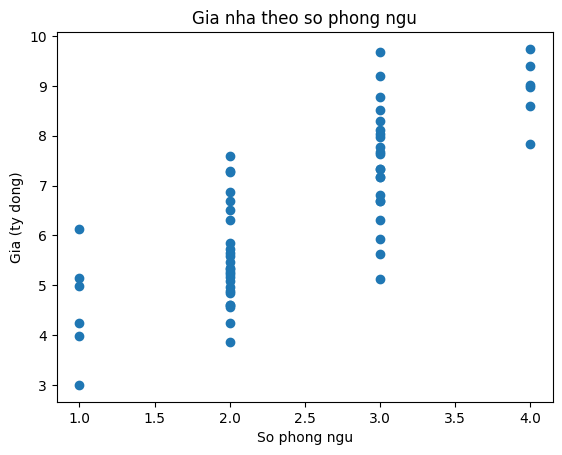

Nhan xet: Gia co xu huong tang khi so phong ngu tang, nhung cac diem trai rong hon nhieu so voi bieu do dien_tich o Muc 3.4, cho thay chi rieng so_phong khong giai thich het duoc bien dong cua gia.


In [46]:
# -*- coding: utf-8 -*-
"""Bai 2: Ve bieu do phan tan giua so_phong va gia."""

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("gia_nha.csv")

# Ve bieu do phan tan: truc ngang la so_phong, truc doc la gia
plt.scatter(df["so_phong"], df["gia"])

# Dat nhan cho hai truc va tieu de cho hinh
plt.xlabel("So phong ngu")
plt.ylabel("Gia (ty dong)")
plt.title("Gia nha theo so phong ngu")

# Luu hinh ra file TRUOC, roi moi hien len man hinh
plt.savefig("bai2.png")
plt.show()

print("Nhan xet: Gia co xu huong tang khi so phong ngu tang, nhung cac diem "
      "trai rong hon nhieu so voi bieu do dien_tich o Muc 3.4, cho thay chi "
      "rieng so_phong khong giai thich het duoc bien dong cua gia.")

He so goc w = -0.037858
He so chan b = 6.983593

Mo hinh: gia = -0.037858 * tuoi_nha + 6.983593

Nhan xet: He so w mang dau am, nghia la nha cang cu (tuoi_nha cang lon) thi gia du doan cang thap. Dieu nay hop ly vi nha moi xay thuong duoc dinh gia cao hon nha da xuong cap, it phai sua chua hon.

Cau hoi them: Nhin bieu do phan tan giua tuoi_nha va gia, cac diem KHONG bam sat quanh mot duong thang nhu bieu do dien_tich o Muc 3.4, ma trai rong hon rat nhieu quanh moi muc tuoi nha. Vi vay he so w co dau dung (am), nhung quan he giua tuoi_nha va gia yeu hon han quan he giua dien_tich va gia. Mot he so co dau dung khong du de ket luan hai dai luong co quan he chat; can nhin them do phan tan cua diem quanh duong thang, hoac tinh MSE/R2, moi danh gia duoc do dang tin cua he so nay.


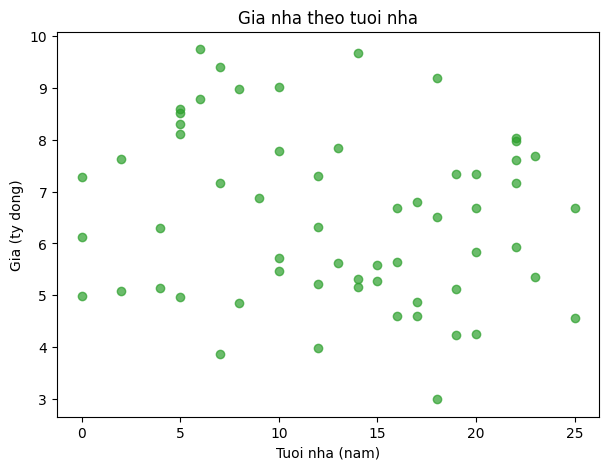

In [40]:
# -*- coding: utf-8 -*-
"""Bai 3: Tim duong hoi quy mot bien, doi x tu dien_tich sang tuoi_nha."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("gia_nha.csv")
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.6f} * tuoi_nha + {b:.6f}")
print()
print("Nhan xet: He so w mang dau am, nghia la nha cang cu (tuoi_nha cang lon) "
      "thi gia du doan cang thap. Dieu nay hop ly vi nha moi xay thuong duoc "
      "dinh gia cao hon nha da xuong cap, it phai sua chua hon.")

# Cau hoi them: ve bieu do phan tan de xem cac diem co bam sat duong thang khong
plt.figure(figsize=(7, 5))
plt.scatter(x, y, color="tab:green", alpha=0.7)
plt.xlabel("Tuoi nha (nam)")
plt.ylabel("Gia (ty dong)")
plt.title("Gia nha theo tuoi nha")
plt.savefig("bai3_scatter.png", dpi=150)

print()
print("Cau hoi them: Nhin bieu do phan tan giua tuoi_nha va gia, cac diem KHONG "
      "bam sat quanh mot duong thang nhu bieu do dien_tich o Muc 3.4, ma trai "
      "rong hon rat nhieu quanh moi muc tuoi nha. Vi vay he so w co dau dung "
      "(am), nhung quan he giua tuoi_nha va gia yeu hon han quan he giua "
      "dien_tich va gia. Mot he so co dau dung khong du de ket luan hai dai "
      "luong co quan he chat; can nhin them do phan tan cua diem quanh duong "
      "thang, hoac tinh MSE/R2, moi danh gia duoc do dang tin cua he so nay.")

In [41]:
# -*- coding: utf-8 -*-
"""Bai 4: Mo hinh hai bien dien_tich va so_phong, so sanh R2 voi mo hinh mot bien."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("gia_nha.csv")
y = df["gia"]
X = df[["dien_tich", "so_phong"]]

# Giu nguyen test_size va random_state de chia dung 48 can hoc, 12 can kiem tra
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)
r2 = r2_score(y_test, y_pred)

r2_mot_bien = 0.9622  # ket qua da co san o Muc 6 cua tai lieu

print(f"R2 tren tap kiem tra (dien_tich + so_phong): {r2:.4f}")
print(f"R2 tren tap kiem tra (chi dien_tich, tu Muc 6): {r2_mot_bien:.4f}")
print()

if r2 > r2_mot_bien:
    print("Nhan xet: Them cot so_phong giup R2 tang so voi mo hinh mot bien, "
          "nen bien nay co dong gop them thong tin huu ich cho viec du doan "
          "gia. Muc tang co the khong lon, vi dien_tich da giai thich phan "
          "lon bien dong cua gia, giong nhu ket qua mo hinh ba bien o Muc 8.")
else:
    print("Nhan xet: Them cot so_phong khong lam R2 tot hon mo hinh mot bien, "
          "cho thay so_phong khong dong gop them nhieu thong tin ngoai nhung "
          "gi dien_tich da the hien, co the vi hai cot nay di kem nhau kha chat "
          "trong bo du lieu (nha rong thuong cung co nhieu phong hon).")

R2 tren tap kiem tra (dien_tich + so_phong): 0.9698
R2 tren tap kiem tra (chi dien_tich, tu Muc 6): 0.9622

Nhan xet: Them cot so_phong giup R2 tang so voi mo hinh mot bien, nen bien nay co dong gop them thong tin huu ich cho viec du doan gia. Muc tang co the khong lon, vi dien_tich da giai thich phan lon bien dong cua gia, giong nhu ket qua mo hinh ba bien o Muc 8.


In [43]:
# -*- coding: utf-8 -*-
"""Bai 5: Chay lai gradient descent voi hai toc do hoc khac nhau: 0.001 va 1.02."""

import numpy as np
import pandas as pd

df = pd.read_csv("gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Chuan hoa dien tich, giong het b6_gradient_descent.py
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

so_vong = 200
n = len(x)


def chay_gradient_descent(toc_do_hoc):
    """Chay du gradient descent so_vong lan, tra ve w, b va MSE cuoi cung."""
    w, b = 0.0, 0.0
    for vong in range(1, so_vong + 1):
        y_du_doan = w * x + b
        chenh_lech = y_du_doan - y

        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()

        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b

    mse_cuoi = (((w * x + b) - y) ** 2).mean()
    return w, b, mse_cuoi


print("So sanh voi toc do hoc = 0.1 trong tai lieu: MSE sau 200 vong = 0.1790")
print()

for toc_do_hoc in [0.001, 1.02]:
    w, b, mse_cuoi = chay_gradient_descent(toc_do_hoc)
    print(f"Toc do hoc = {toc_do_hoc}")
    print(f"  w sau 200 vong = {w:.6f}")
    print(f"  b sau 200 vong = {b:.6f}")
    print(f"  MSE sau 200 vong = {mse_cuoi:.6f}")
    print()

print("Giai thich: Voi toc do hoc 0.001, moi buoc di qua ngan (giong xuong doi "
      "bang buoc mot xang-ti-met), nen sau 200 vong van con cach xa day cua "
      "duong cong MSE, MSE con lai rat lon. Voi toc do hoc 1.02, moi buoc di "
      "qua dai nen w va b nhay vot qua day sang phia doi dien roi lai nhay "
      "ngugc ve xa hon nua, khien MSE tang theo cap so nhan qua moi vong thay "
      "vi giam dan.")

print()
print("Lam them: do mot vai toc do hoc o giua de tim ranh gioi on dinh.")
for toc_do_hoc in [0.5, 0.9, 1.0, 1.01]:
    w, b, mse_cuoi = chay_gradient_descent(toc_do_hoc)
    print(f"  toc do hoc = {toc_do_hoc:5.3f}  ->  MSE sau 200 vong = {mse_cuoi:.6f}")

So sanh voi toc do hoc = 0.1 trong tai lieu: MSE sau 200 vong = 0.1790

Toc do hoc = 0.001
  w sau 200 vong = 0.518434
  b sau 200 vong = 2.142465
  MSE sau 200 vong = 20.217521

Toc do hoc = 1.02
  w sau 200 vong = -4006.316481
  b sau 200 vong = -16556.375310
  MSE sau 200 vong = 290391782.019229

Giai thich: Voi toc do hoc 0.001, moi buoc di qua ngan (giong xuong doi bang buoc mot xang-ti-met), nen sau 200 vong van con cach xa day cua duong cong MSE, MSE con lai rat lon. Voi toc do hoc 1.02, moi buoc di qua dai nen w va b nhay vot qua day sang phia doi dien roi lai nhay ngugc ve xa hon nua, khien MSE tang theo cap so nhan qua moi vong thay vi giam dan.

Lam them: do mot vai toc do hoc o giua de tim ranh gioi on dinh.
  toc do hoc = 0.500  ->  MSE sau 200 vong = 0.179025
  toc do hoc = 0.900  ->  MSE sau 200 vong = 0.179025
  toc do hoc = 1.000  ->  MSE sau 200 vong = 44.811257
  toc do hoc = 1.010  ->  MSE sau 200 vong = 122947.000880


In [44]:
# -*- coding: utf-8 -*-
"""Bai 6: Ham du doan gia tu dien tich, co canh bao khi ra ngoai vung du lieu."""

# Hai he so nay lay tu ket qua mo hinh mot bien o Muc 5, khong can huan luyen lai
W = 0.078367
B = 0.401752

DIEN_TICH_MIN = 35.5
DIEN_TICH_MAX = 117.5


def du_doan_gia(dien_tich):
    """Du doan gia nha (ty dong) tu dien tich (m2).

    In canh bao neu dien tich nam ngoai khoang du lieu da dung de hoc,
    vi ngoai khoang do ket qua chi la ngoai suy (extrapolation), khong
    con can ho thuc te nao de doi chieu.
    """
    if dien_tich < DIEN_TICH_MIN or dien_tich > DIEN_TICH_MAX:
        print(f"  Canh bao: dien tich {dien_tich} m2 nam ngoai khoang du lieu "
              f"da hoc ({DIEN_TICH_MIN} toi {DIEN_TICH_MAX} m2). Ket qua du "
              f"doan la ngoai suy, do tin cay thap.")
    gia_du_doan = W * dien_tich + B
    return gia_du_doan


for dien_tich in [60, 80, 200]:
    gia = du_doan_gia(dien_tich)
    print(f"Can {dien_tich} m2 -> du doan {gia:.3f} ty dong")
    print()

Can 60 m2 -> du doan 5.104 ty dong

Can 80 m2 -> du doan 6.671 ty dong

  Canh bao: dien tich 200 m2 nam ngoai khoang du lieu da hoc (35.5 toi 117.5 m2). Ket qua du doan la ngoai suy, do tin cay thap.
Can 200 m2 -> du doan 16.075 ty dong

